<a href="https://colab.research.google.com/github/nazartkachenkowork-rgb/lab_ksvd/blob/main/%D0%A2%D0%BA%D0%B0%D1%87%D0%B5%D0%BD%D0%BA%D0%BE_%D0%9D_%D0%92_%D0%9F%D1%96%D0%B4%D1%81%D1%83%D0%BC%D0%BA%D0%BE%D0%B2%D0%B0_%D0%9A%D0%A0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Завдання 1

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [18]:
from google.colab import files
uploaded = files.upload()

Saving Global YouTube Statistics.csv to Global YouTube Statistics (1).csv


In [19]:
youtube_name = list(uploaded.keys())[0]
df1 = pd.read_csv(youtube_name, encoding='latin-1')

print('Файл завантажено:', youtube_name)

Файл завантажено: Global YouTube Statistics (1).csv


In [20]:
df1.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [21]:
print('Розмір датасету:', df1.shape)
print('\nКількість пропусків:')
print(df1.isnull().sum())
print('\nКількість дублікатів:', df1.duplicated().sum())

Розмір датасету: (995, 28)

Кількість пропусків:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_mon

In [22]:
for col in df1.columns:
    temp = pd.to_numeric(df1[col].astype(str).str.replace(',', '', regex=False), errors='coerce')
    if df1[col].isnull().sum() > 0 and temp.notnull().sum() > 0:
        df1[col] = temp.astype(float)
        df1[col] = df1[col].fillna(df1[col].mean())

print('Пропуски після заповнення:')
print(df1.isnull().sum())

Пропуски після заповнення:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             0
country_rank                                 0
channel_type_rank                            0
video_views_for_the_last_30_days             0
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days                 0
created_year                                 0
created_month                    

In [23]:
print('Кількість унікальних країн:', df1['Country'].nunique())

Кількість унікальних країн: 49


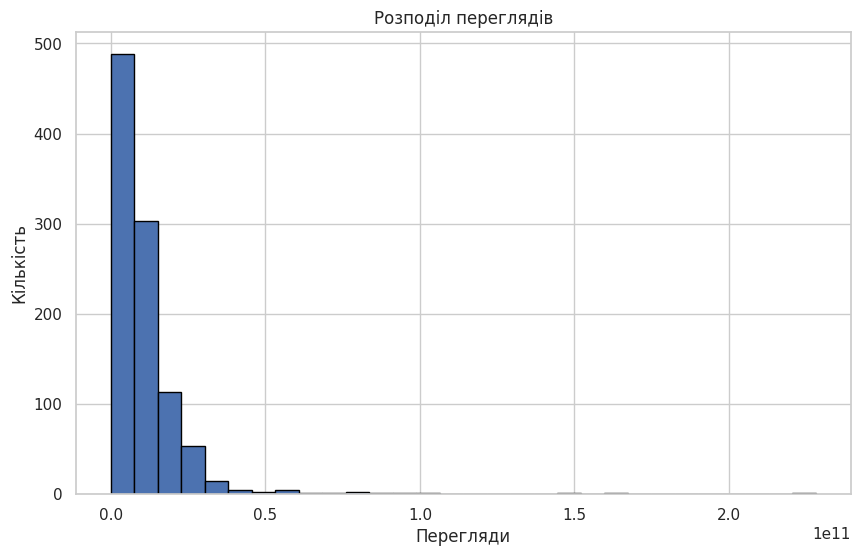

In [24]:
df1['video views'] = pd.to_numeric(
    df1['video views'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

df1['video views'].plot(kind='hist', bins=30, edgecolor='black')
plt.title('Розподіл переглядів')
plt.xlabel('Перегляди')
plt.ylabel('Кількість')
plt.show()

In [25]:
print('Максимальна кількість переглядів:', df1['video views'].max())
print('Мінімальна кількість переглядів:', df1['video views'].min())
print('Середня кількість переглядів:', df1['video views'].mean())

Максимальна кількість переглядів: 228000000000.0
Мінімальна кількість переглядів: 0.0
Середня кількість переглядів: 11039537052.03819


In [26]:
df1['uploads'] = pd.to_numeric(
    df1['uploads'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

country_stat = df1.groupby('Country')['uploads'].sum().sort_values(ascending=False)

print('Країна, де найбільше відео завантажено на YouTube:', country_stat.index[0])

Країна, де найбільше відео завантажено на YouTube: India


In [27]:
name_col = 'Youtuber'
if 'Title' in df1.columns:
    name_col = 'Title'

max_row = df1.loc[df1['uploads'].idxmax()]
min_row = df1.loc[df1['uploads'].idxmin()]

print('Назва з найбільшою кількістю завантажень:')
print(max_row[name_col])

print('\nНазва з найменшою кількістю завантажень:')
print(min_row[name_col])

Назва з найбільшою кількістю завантажень:
ABP NEWS

Назва з найменшою кількістю завантажень:
Music


Завдання 2

In [28]:
from google.colab import files
uploaded2 = files.upload()

Saving shopping_trends.csv to shopping_trends (1).csv


In [29]:
shopping_name = list(uploaded2.keys())[0]
df2 = pd.read_csv(shopping_name)

print('Файл завантажено:', shopping_name)

Файл завантажено: shopping_trends (1).csv


In [30]:
print('Розмір таблиці:', df2.shape)
print('\nПропуски:')
print(df2.isnull().sum())
print('\nТипи стовпців:')
print(df2.dtypes)

Розмір таблиці: (3900, 19)

Пропуски:
Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

Типи стовпців:
Customer ID                   int64
Age                           int64
Gender                       object
Item Purchased               object
Category                     object
Purchase Amount (USD)         int64
Location                     object
Size                         object
Color                        object
Season                       object
Rev

In [33]:
df2.columns = (
    df2.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace(r'[()]', '', regex=True)
)

print(df2.columns.tolist())

['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount_usd', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'payment_method', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'preferred_payment_method', 'frequency_of_purchases']


In [35]:
if 'purchase_amount_usd' in df2.columns:
    money_col = 'purchase_amount_usd'
elif 'purchase_amount' in df2.columns:
    money_col = 'purchase_amount'
elif 'purchase_amount_usd_' in df2.columns:
    money_col = 'purchase_amount_usd_'
elif 'purchase_amount_(usd)' in df2.columns:
    money_col = 'purchase_amount_(usd)'
else:
    print(df2.columns.tolist())
    raise KeyError('Не знайдено колонку з сумою покупки')

df2['age'] = pd.to_numeric(df2['age'], errors='coerce')
df2[money_col] = pd.to_numeric(df2[money_col], errors='coerce')
df2['review_rating'] = pd.to_numeric(df2['review_rating'], errors='coerce')

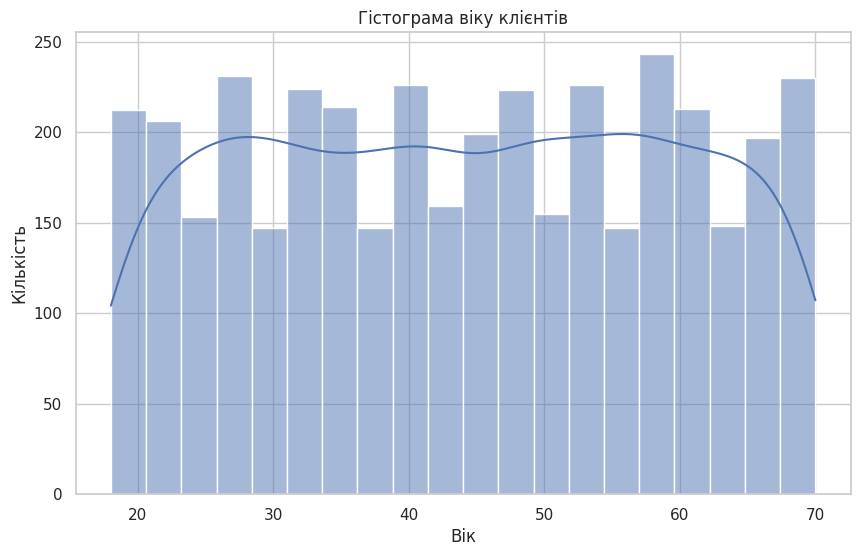

In [36]:
sns.histplot(df2['age'], bins=20, kde=True)
plt.title('Гістограма віку клієнтів')
plt.xlabel('Вік')
plt.ylabel('Кількість')
plt.show()

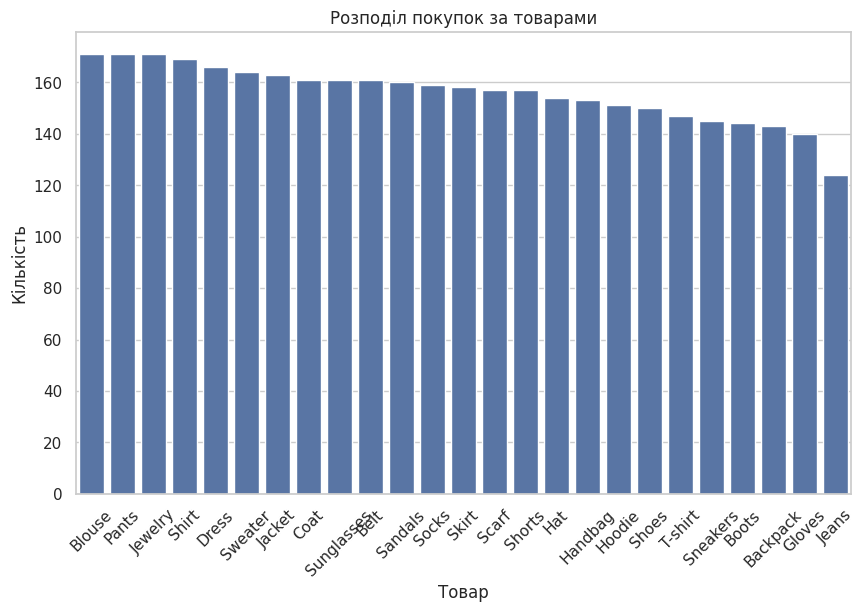

In [37]:
popular_items = df2['item_purchased'].value_counts().reset_index()
popular_items.columns = ['item_purchased', 'count']

sns.barplot(data=popular_items, x='item_purchased', y='count')
plt.title('Розподіл покупок за товарами')
plt.xlabel('Товар')
plt.ylabel('Кількість')
plt.xticks(rotation=45)
plt.show()

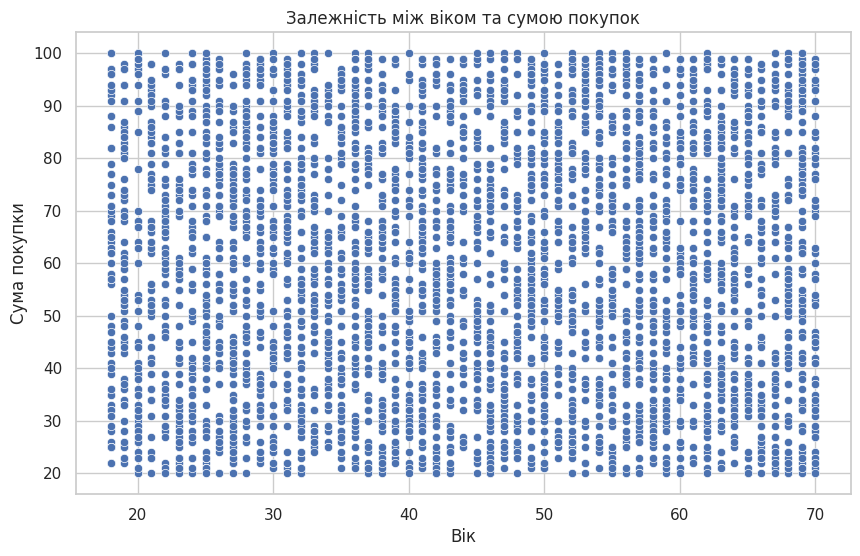

In [38]:
sns.scatterplot(data=df2, x='age', y=money_col)
plt.title('Залежність між віком та сумою покупок')
plt.xlabel('Вік')
plt.ylabel('Сума покупки')
plt.show()

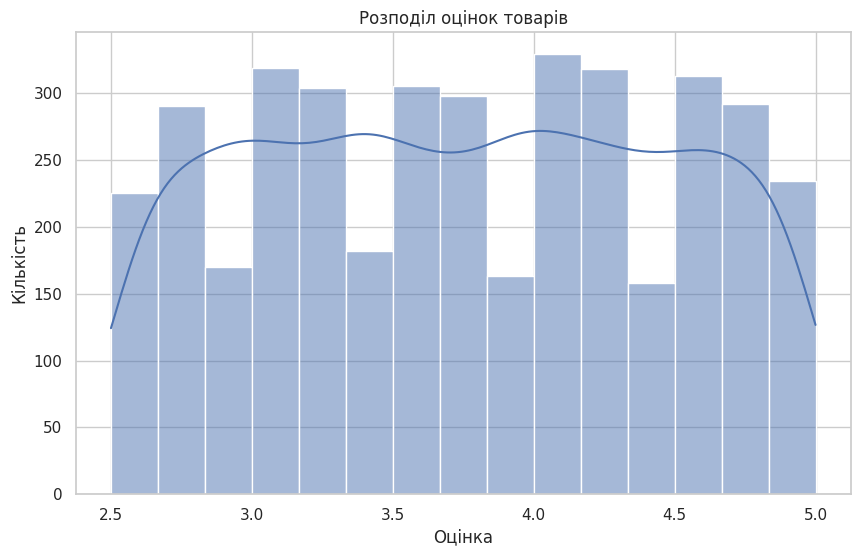

In [39]:
sns.histplot(df2['review_rating'], bins=15, kde=True)
plt.title('Розподіл оцінок товарів')
plt.xlabel('Оцінка')
plt.ylabel('Кількість')
plt.show()

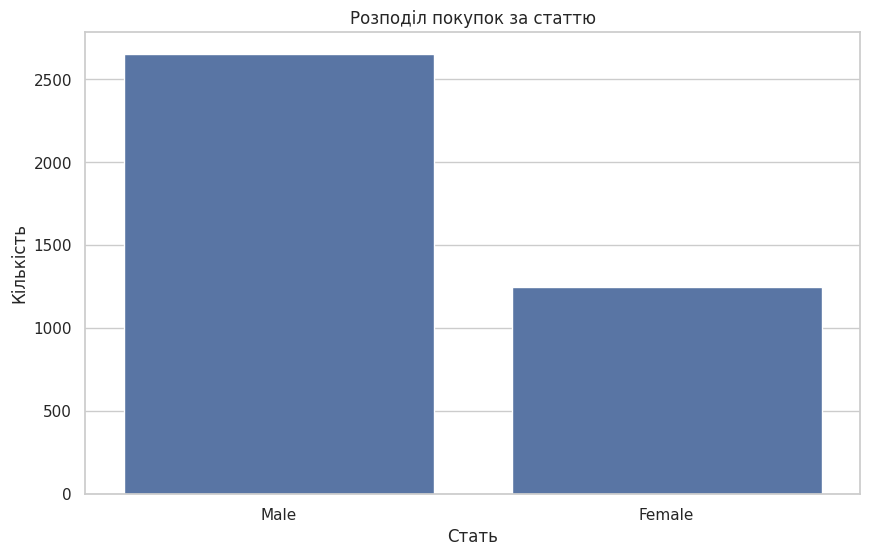

In [40]:
sns.countplot(data=df2, x='gender')
plt.title('Розподіл покупок за статтю')
plt.xlabel('Стать')
plt.ylabel('Кількість')
plt.show()

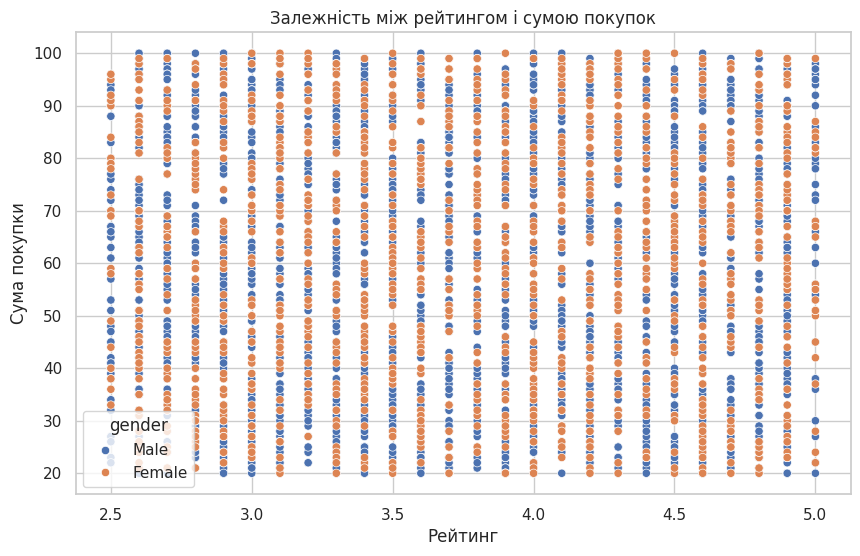

In [41]:
sns.scatterplot(data=df2, x='review_rating', y=money_col, hue='gender')
plt.title('Залежність між рейтингом і сумою покупок')
plt.xlabel('Рейтинг')
plt.ylabel('Сума покупки')
plt.show()

Завдання 3

In [42]:
!pip install altair vega_datasets plotly -q

In [43]:
import altair as alt
import plotly.express as px
from vega_datasets import data

alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

In [44]:
wheat = data.wheat()

bars = alt.Chart(wheat).mark_bar().encode(
    x=alt.X('wheat:Q', title='Врожайність пшениці'),
    y=alt.Y('year:O', title='Рік')
)

text = alt.Chart(wheat).mark_text(
    align='left',
    baseline='middle',
    dx=4
).encode(
    x='wheat:Q',
    y='year:O',
    text=alt.Text('wheat:Q', format='.1f')
)

chart1 = (bars + text).properties(title='Врожайність пшениці за роками')
chart1

alt.LayerChart(...)

In [50]:
electricity = data.iowa_electricity()

chart2 = alt.Chart(electricity).mark_area(opacity=0.7).encode(
    x=alt.X('year:T', title='Рік'),
    y=alt.Y('net_generation:Q', title='Чисте виробництво електроенергії'),
    color=alt.Color('source:N', title='Джерело'),
    tooltip=[
        alt.Tooltip('year:T', title='Рік'),
        alt.Tooltip('source:N', title='Джерело'),
        alt.Tooltip('net_generation:Q', title='Виробництво')
    ]
).properties(
    title='Виробництво електроенергії в штаті Айова'
)

chart2

alt.Chart(...)

In [51]:
iris = px.data.iris()

fig = px.scatter(
    iris,
    x='sepal_width',
    y='sepal_length',
    size='petal_length',
    color='species',
    hover_data=['petal_width'],
    title='Розсіювання ірисів'
)

fig.show()